# Optimized Version of `galton_basic.ipynb`

The aforementioned notebook, although physically accurate, is incredibly slow, thus this notebook explores various ways to optimize it speed-wise.

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.cm import get_cmap

import sympy as sym
from sympy import symbols, Eq, solve

x, y = symbols('x y')

### v1
Naive one-by-one looping architecture.

We begin with the streamlined code from `galton_basic.ipynb` without its visualization components.

In [13]:
def generate_circle_geometry(n_first_row, n_rows, d, h_init, r_custom, WALL_PADDING=0):
    """Generates SymPy circle objects and equations based on grid constraints.

    Building DOWNWARD from the initial row.
    """
    x, y = sym.symbols("x y")
    circles_data = []
    max_edge_distance = 0  # Track the furthest edge from x=0

    # Calculate row height step for an equilateral triangle lattice
    row_height_step = d * (3**0.5) / 2

    for row_idx in range(n_rows):
        # Determine number of circles in this row (staggered n, n-1, n, n-1...)
        is_even_row = row_idx % 2 == 0
        row_count = n_first_row if is_even_row else n_first_row - 1

        # Subtract the step so subsequent rows go DOWNWARD
        y_center = -h_init - (row_idx * row_height_step)

        # Calculate the starting X coordinate to keep the row symmetric about x=0
        start_x = -((row_count - 1) * d) / 2

        for col_idx in range(row_count):
            x_center = start_x + (col_idx * d)

            # Track the maximum absolute distance from x=0 to the outer edge of the circle
            furthest_edge = abs(x_center) + r_custom
            if furthest_edge > max_edge_distance:
                max_edge_distance = furthest_edge

            # SymPy Equation: (x - x_c)^2 + (y - y_c)^2 = r_custom^2
            equation = sym.Eq(
                (x - x_center) ** 2 + (y - y_center) ** 2, r_custom**2
            )

            circles_data.append(
                {
                    "center": (x_center, y_center),
                    "radius": r_custom,
                    "eq": equation,
                }
            )

    # Calculate final WALL_DISTANCE by adding the padding
    WALL_DISTANCE = max_edge_distance + WALL_PADDING

    return circles_data, WALL_DISTANCE

In [14]:
N_FIRST_ROW = 30     # Number of circles in the first row
N_ROWS = 30          # Total number of rows (staggered)
DISTANCE = 2.0      # Center-to-center distance (d)
H_INIT = 3.0        # Initial offset below the x-axis
H_FINAL = 1.0       # Final offset below the x-axis (not used in this code)
RADIUS = 0.75       # Custom radius for all circles
WALL_PADDING = 0.5  # Distance of the wall away from the furthest circle edge

# Generate data
generated_circles, WALL_DISTANCE = generate_circle_geometry(
        n_first_row=N_FIRST_ROW,
        n_rows=N_ROWS,
        d=DISTANCE,
        h_init=H_INIT,
        r_custom=RADIUS,
        WALL_PADDING=WALL_PADDING
    )

In [ ]:
def simulate_trajectory(circles_data, x_init, y_init, vx_init, vy_init, 
                        e, h_init, rows, spacing, h_final, WALL_DISTANCE, g=9.81):
    """
    Fixed Galton board simulation focusing purely on physics and calculation.
    Resolves floating-point root rejection, parabolic tunneling, and includes bounding walls.
    """
    # Target line extends DOWNWARD
    y_target = -h_init - (rows * spacing * np.cos(np.radians(30))) - h_final
    
    x_imp, y_imp = x_init, y_init
    vx, vy = vx_init, vy_init
    
    c4 = 0.25 * (g**2)
    step = 0
    is_final_step = False
    
    while True:
        step += 1
        
        # 1. Time-to-line solver (Detection Line)
        a_line = 0.5 * g
        b_line = -vy
        c_line = y_target - y_imp
        discriminant = b_line**2 - 4 * a_line * c_line
        
        t_line = float('inf')
        if discriminant >= 0:
            t_candidates = [
                (-b_line + np.sqrt(discriminant)) / (2 * a_line),
                (-b_line - np.sqrt(discriminant)) / (2 * a_line)
            ]
            valid_line_times = [t for t in t_candidates if t > 1e-5]
            if valid_line_times:
                t_line = min(valid_line_times)

        # 2. Time-to-wall solver
        t_wall = float('inf')
        hit_wall_side = None
        
        if vx < 0: # Moving left
            t_left = (-WALL_DISTANCE - x_imp) / vx
            if t_left > 1e-5:
                t_wall = t_left
                hit_wall_side = 'left'
        elif vx > 0: # Moving right
            t_right = (WALL_DISTANCE - x_imp) / vx
            if t_right > 1e-5:
                t_wall = t_right
                hit_wall_side = 'right'

        # 3. Local peg scanning loop
        min_t_circle = float('inf')
        next_peg = None
        
        for circle in circles_data:
            xc, yc = circle["center"]
            R = circle["radius"]
            
            if yc > y_imp + 2.0 * spacing:
                continue
                
            dx = x_imp - xc
            dy = y_imp - yc
            
            c3 = -vy * g
            c2 = (vx**2) + (vy**2) - (dy * g)
            c1 = 2.0 * (dx * vx + dy * vy)
            c0 = (dx**2) + (dy**2) - (R**2)
            
            roots = np.roots([c4, c3, c2, c1, c0])
            for r in roots:
                if abs(r.imag) < 1e-6:
                    t_val = r.real
                    if 1e-5 < t_val < min_t_circle:
                        min_t_circle = t_val
                        next_peg = (xc, yc, R)

        # Intersect evaluation (Find earliest valid event)
        event_times = {'line': t_line, 'peg': min_t_circle, 'wall': t_wall}
        valid_events = {k: v for k, v in event_times.items() if v != float('inf')}
        
        if not valid_events:
            print(f"Simulation out of bounds at step {step}. No intersections found.")
            break
            
        next_event = min(valid_events, key=valid_events.get)
        t_end = valid_events[next_event]
        is_final_step = (next_event == 'line')

        # Calculate final state at the end of this linear/parabolic segment
        x_next = x_imp + vx * t_end
        y_next = y_imp + vy * t_end - 0.5 * g * t_end**2
        
        if is_final_step:
            print(f"Success! Detection line hit at X = {x_next:.6f}")
            return True, x_next

        # Process Physics for bouncing
        vx_before = vx
        vy_before = vy - g * t_end

        if next_event == 'peg':
            xc, yc, R = next_peg
            nx = (x_next - xc) / R
            ny = (y_next - yc) / R
            
            v_dot_n = vx_before * nx + vy_before * ny
            vx_after = vx_before - (1 + e) * v_dot_n * nx
            vy_after = vy_before - (1 + e) * v_dot_n * ny
            
            x_imp = x_next + (nx * 1e-4)
            y_imp = y_next + (ny * 1e-4)
            
        elif next_event == 'wall':
            vx_after = -e * vx_before
            vy_after = vy_before
            
            nx = 1.0 if hit_wall_side == 'left' else -1.0
            x_imp = x_next + (nx * 1e-4)
            y_imp = y_next 
            
        vx, vy = vx_after, vy_after
        
        if step > 500:
            print("Infinite loop fallback safety triggered.")
            break

    return False, None

Function to run massive numbers of balls through `simulate_trajectory()`.

In [16]:
def run_and_plot_galton_batch(n_balls, n_bins, generated_circles, H_INIT=H_INIT, N_ROWS=N_ROWS, 
                              DISTANCE=DISTANCE, H_FINAL=H_FINAL, WALL_DISTANCE=WALL_DISTANCE, x_drop_range=(-1, 1),
                              show_plot=True):
    """
    Generates random entry positions for a batch of balls, runs the simulation 
    for each, calculates the histogram data, and graphs it using matplotlib.
    """
    
    # Define where the balls are allowed to drop from at the top
    if x_drop_range is None:
        drop_min, drop_max = -DISTANCE, DISTANCE
    else:
        drop_min, drop_max = x_drop_range

    # Generate n_balls uniform random values for x_init
    x_init_values = np.random.uniform(drop_min, drop_max, size=n_balls)
    
    final_x_positions = []
    
    # Run the simulation for each ball
    for x_val in x_init_values:
        success, final_x = simulate_trajectory(
            circles_data=generated_circles,
            x_init=x_val,
            y_init=0.0,
            vx_init=1.0,
            vy_init=0.0,
            e=0.9,
            h_init=H_INIT,
            rows=N_ROWS,
            spacing=DISTANCE,
            h_final=H_FINAL,
            WALL_DISTANCE=WALL_DISTANCE
        )
        
        if success:
            final_x_positions.append(final_x)
            
    # Calculate the histogram strictly bounded by the wall positions
    counts, bin_edges = np.histogram(
        final_x_positions, 
        bins=n_bins, 
        range=(-WALL_DISTANCE, WALL_DISTANCE)
    )
    
    # --- Matplotlib Graphing Functionality ---
    if show_plot and len(final_x_positions) > 0:
        plt.figure(figsize=(10, 6))
        
        # Calculate width of individual bins for the bar chart
        bin_width = np.diff(bin_edges)
        
        # Plot using plt.bar for exact alignment with np.histogram
        plt.bar(
            bin_edges[:-1], 
            counts, 
            width=bin_width, 
            color='#3498db', 
            edgecolor='#2980b9', 
            alpha=0.8, 
            align='edge',
            label=f'Balls Reached Line ({len(final_x_positions)}/{n_balls})'
        )
        
        # Visual styling
        plt.xlim(-WALL_DISTANCE, WALL_DISTANCE)
        plt.axvline(x=0, color='#e74c3c', linestyle=':', alpha=0.7, label='Centerline')
        plt.title(f'Galton Board Final Ball Distribution ({n_bins} Bins)', fontsize=14, fontweight='bold')
        plt.xlabel('X Coordinate at Detection Line', fontsize=12)
        plt.ylabel('Ball Count', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(loc='upper right')
        
        plt.tight_layout()
        plt.show()
    elif len(final_x_positions) == 0:
        print("No balls successfully reached the detection line. Skipping plot.")
    
    return counts, bin_edges

Success! Detection line hit at X = -4.264995
Success! Detection line hit at X = -0.928249
Success! Detection line hit at X = 1.602624
Success! Detection line hit at X = 4.544835
Success! Detection line hit at X = -6.917881
Success! Detection line hit at X = -20.428438
Success! Detection line hit at X = 21.368810
Success! Detection line hit at X = 11.529629
Success! Detection line hit at X = -8.142867
Success! Detection line hit at X = -5.363947


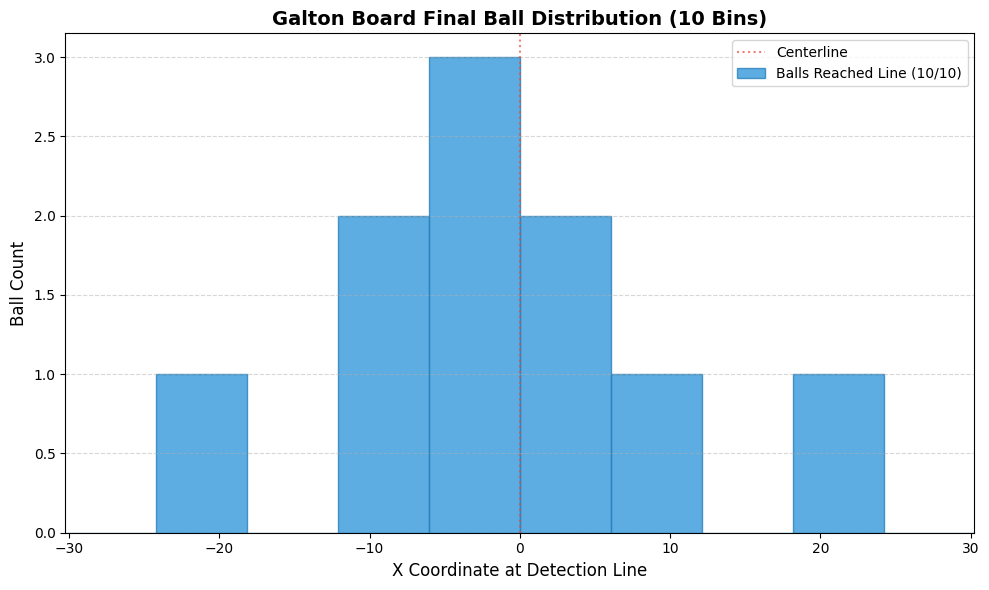

(array([0, 1, 0, 2, 3, 2, 1, 0, 1, 0]),
 array([-30.25, -24.2 , -18.15, -12.1 ,  -6.05,   0.  ,   6.05,  12.1 ,
         18.15,  24.2 ,  30.25]))

In [18]:
run_and_plot_galton_batch(n_balls=10, n_bins=10, generated_circles=generated_circles)
    

### v2

Implement multiprocessing and spatial hashing for time optimization, note that a key weakness of this approach is that if the pegs were to move in the future (such as in vibrations), the spatial grid would have to constantly be updated, which would be a challenge. But then again, moving the grid itself without disrupting the non-time-iterative nature of the code would be another challenge in and of itself.

In [19]:
from concurrent.futures import ProcessPoolExecutor

In [24]:
def generate_circle_geometry(n_first_row, n_rows, d, h_init, r_custom, WALL_PADDING=0):
    circles_data = []
    max_edge_distance = 0
    row_height_step = d * (3**0.5) / 2

    for row_idx in range(n_rows):
        is_even_row = row_idx % 2 == 0
        row_count = n_first_row if is_even_row else n_first_row - 1
        y_center = -h_init - (row_idx * row_height_step)
        start_x = -((row_count - 1) * d) / 2

        for col_idx in range(row_count):
            x_center = start_x + (col_idx * d)
            furthest_edge = abs(x_center) + r_custom
            if furthest_edge > max_edge_distance:
                max_edge_distance = furthest_edge

            circles_data.append({
                "center": (x_center, y_center),
                "radius": r_custom,
            })

    WALL_DISTANCE = max_edge_distance + WALL_PADDING
    return circles_data, WALL_DISTANCE

This is where the new spatial hashing code comes in.

In [25]:
def build_spatial_grid(circles_data, cell_size):
    """Maps static circles into discrete grid cells to achieve O(1) local lookups."""
    spatial_grid = {}
    for circle in circles_data:
        xc, yc = circle["center"]
        r = circle["radius"]
        
        # Determine cell bounds covering the circle's footprint
        x_min_cell = int(np.floor((xc - r) / cell_size))
        x_max_cell = int(np.floor((xc + r) / cell_size))
        y_min_cell = int(np.floor((yc - r) / cell_size))
        y_max_cell = int(np.floor((yc + r) / cell_size))
        
        for cx in range(x_min_cell, x_max_cell + 1):
            for cy in range(y_min_cell, y_max_cell + 1):
                if (cx, cy) not in spatial_grid:
                    spatial_grid[(cx, cy)] = []
                spatial_grid[(cx, cy)].append(circle)
    return spatial_grid

Basically same simulation function as before, but added spatial hashing.

In [26]:
def simulate_trajectory(spatial_grid, cell_size, radius, x_init, y_init, vx_init, vy_init, 
                        e, h_init, rows, spacing, h_final, WALL_DISTANCE, g=9.81):
    """
    Simulates a ball trajectory using spatial grid culling and exact quartic physics.
    """
    y_target = -h_init - (rows * spacing * np.cos(np.radians(30))) - h_final
    x_imp, y_imp = x_init, y_init
    vx, vy = vx_init, vy_init
    
    c4 = 0.25 * (g**2)
    step = 0
    
    while True:
        step += 1
        
        # 1. Time-to-line solver (Detection Line)
        a_line = 0.5 * g
        b_line = -vy
        c_line = y_target - y_imp
        discriminant = b_line**2 - 4 * a_line * c_line
        
        t_line = float('inf')
        if discriminant >= 0:
            t_candidates = [
                (-b_line + np.sqrt(discriminant)) / (2 * a_line),
                (-b_line - np.sqrt(discriminant)) / (2 * a_line)
            ]
            valid_line_times = [t for t in t_candidates if t > 1e-5]
            if valid_line_times:
                t_line = min(valid_line_times)

        # 2. Time-to-wall solver
        t_wall = float('inf')
        hit_wall_side = None
        if vx < 0:
            t_left = (-WALL_DISTANCE - x_imp) / vx
            if t_left > 1e-5:
                t_wall = t_left
                hit_wall_side = 'left'
        elif vx > 0:
            t_right = (WALL_DISTANCE - x_imp) / vx
            if t_right > 1e-5:
                t_wall = t_right
                hit_wall_side = 'right'

        # 3. Dynamic Bounding Box + Spatial Grid Query
        t_max = min(t_line, t_wall)
        if t_max == float('inf'):
            break

        # Calculate exact parabolic arc spatial boundaries for this specific step
        x0, x1 = x_imp, x_imp + vx * t_max
        x_min, x_max = min(x0, x1), max(x0, x1)

        y0 = y_imp
        y1 = y_imp + vy * t_max - 0.5 * g * (t_max**2)
        y_min, y_max = min(y0, y1), max(y0, y1)

        # Accountability check for parabolic peak vertex
        t_vertex = vy / g
        if 0 < t_vertex < t_max:
            y_vertex = y_imp + (vy**2) / (2 * g)
            y_max = max(y_max, y_vertex)

        # Convert bounding spatial coordinates into grid keys (including peg physical profile)
        cx_start = int(np.floor((x_min - radius) / cell_size))
        cx_end = int(np.floor((x_max + radius) / cell_size))
        cy_start = int(np.floor((y_min - radius) / cell_size))
        cy_end = int(np.floor((y_max + radius) / cell_size))

        # Gather deduplicated candidate pegs within the flight path zone
        candidate_circles = []
        seen_centers = set()
        for cx in range(cx_start, cx_end + 1):
            for cy in range(cy_start, cy_end + 1):
                if (cx, cy) in spatial_grid:
                    for circle in spatial_grid[(cx, cy)]:
                        center = circle["center"]
                        if center not in seen_centers:
                            seen_centers.add(center)
                            candidate_circles.append(circle)

        # 4. Local analytical scanning loop
        min_t_circle = float('inf')
        next_peg = None
        
        for circle in candidate_circles:
            xc, yc = circle["center"]
            R = radius
            
            dx = x_imp - xc
            dy = y_imp - yc
            
            c3 = -vy * g
            c2 = (vx**2) + (vy**2) - (dy * g)
            c1 = 2.0 * (dx * vx + dy * vy)
            c0 = (dx**2) + (dy**2) - (R**2)
            
            roots = np.roots([c4, c3, c2, c1, c0])
            for r in roots:
                if abs(r.imag) < 1e-6:
                    t_val = r.real
                    if 1e-5 < t_val < min_t_circle:
                        min_t_circle = t_val
                        next_peg = (xc, yc, R)

        # 5. Intersect evaluation
        event_times = {'line': t_line, 'peg': min_t_circle, 'wall': t_wall}
        valid_events = {k: v for k, v in event_times.items() if v != float('inf')}
        
        if not valid_events:
            break
            
        next_event = min(valid_events, key=valid_events.get)
        t_end = valid_events[next_event]
        is_final_step = (next_event == 'line')

        x_next = x_imp + vx * t_end
        y_next = y_imp + vy * t_end - 0.5 * g * t_end**2
        
        if is_final_step:
            return True, x_next

        vx_before = vx
        vy_before = vy - g * t_end

        if next_event == 'peg':
            xc, yc, R = next_peg
            nx = (x_next - xc) / R
            ny = (y_next - yc) / R
            
            v_dot_n = vx_before * nx + vy_before * ny
            vx_after = vx_before - (1 + e) * v_dot_n * nx
            vy_after = vy_before - (1 + e) * v_dot_n * ny
            
            x_imp = x_next + (nx * 1e-4)
            y_imp = y_next + (ny * 1e-4)
            
        elif next_event == 'wall':
            vx_after = -e * vx_before
            vy_after = vy_before
            
            nx = 1.0 if hit_wall_side == 'left' else -1.0
            x_imp = x_next + (nx * 1e-4)
            y_imp = y_next 
            
        vx, vy = vx_after, vy_after
        
        if step > 1000:
            break

    return False, None

Multiprocessing and batch worker code.

In [27]:
def _simulation_worker(args):
    """Top-level un-nested function compatible with process serialization."""
    return simulate_trajectory(*args)

def run_and_plot_galton_batch(n_balls, n_bins, spatial_grid, cell_size,
                              H_INIT, N_ROWS, DISTANCE, H_FINAL, WALL_DISTANCE, RADIUS, x_drop_range=(-1, 1)):
    
    if x_drop_range is None:
        drop_min, drop_max = -DISTANCE, DISTANCE
    else:
        drop_min, drop_max = x_drop_range

    x_init_values = np.random.uniform(drop_min, drop_max, size=n_balls)
    
    # Bundle invariant arguments into target payloads
    tasks = [
        (spatial_grid, cell_size, RADIUS, x_val, 0.0, 1.0, 0.0, 0.9, 
         H_INIT, N_ROWS, DISTANCE, H_FINAL, WALL_DISTANCE)
        for x_val in x_init_values
    ]
    
    final_x_positions = []
    
    print(f"Launching batch execution of {n_balls} balls using available CPU Cores...")
    with ProcessPoolExecutor() as executor:
        results = executor.map(_simulation_worker, tasks)
        for success, final_x in results:
            if success:
                final_x_positions.append(final_x)
                
    counts, bin_edges = np.histogram(final_x_positions, bins=n_bins, range=(-WALL_DISTANCE, WALL_DISTANCE))
    
    if len(final_x_positions) > 0:
        plt.figure(figsize=(10, 6))
        bin_width = np.diff(bin_edges)
        plt.bar(bin_edges[:-1], counts, width=bin_width, color='#3498db', edgecolor='#2980b9', alpha=0.8, align='edge',
                label=f'Balls Reached Line ({len(final_x_positions)}/{n_balls})')
        plt.xlim(-WALL_DISTANCE, WALL_DISTANCE)
        plt.axvline(x=0, color='#e74c3c', linestyle=':', alpha=0.7, label='Centerline')
        plt.title(f'Galton Board Final Ball Distribution ({n_bins} Bins)', fontsize=14, fontweight='bold')
        plt.xlabel('X Coordinate at Detection Line', fontsize=12)
        plt.ylabel('Ball Count', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()
        
    return counts, bin_edges


In [28]:
N_FIRST_ROW = 30     
N_ROWS = 30          
DISTANCE = 2.0      
H_INIT = 3.0        
H_FINAL = 1.0       
RADIUS = 0.75       
WALL_PADDING = 0.5  
CELL_SIZE = DISTANCE # Optimized hash grid size scales directly with peg intervals

generated_circles, WALL_DISTANCE = generate_circle_geometry(
    n_first_row=N_FIRST_ROW, n_rows=N_ROWS, d=DISTANCE, h_init=H_INIT, r_custom=RADIUS, WALL_PADDING=WALL_PADDING
)

# Initialize static spatial hash map
spatial_grid = build_spatial_grid(generated_circles, cell_size=CELL_SIZE)

# Run 5,000 balls safely and rapidly
run_and_plot_galton_batch(
    n_balls=100, 
    n_bins=25,
    spatial_grid=spatial_grid,
    cell_size=CELL_SIZE,
    H_INIT=H_INIT,
    N_ROWS=N_ROWS,
    DISTANCE=DISTANCE,
    H_FINAL=H_FINAL,
    WALL_DISTANCE=WALL_DISTANCE,
    RADIUS=RADIUS
)

Launching batch execution of 100 balls using available CPU Cores...


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.